In [2]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import multivariate_normal

# TOPIC 1

## 1) (Score: 15%) Briefly write the steps (with relevant formulas) that you would perform to estimate the means μ(1) 1 and μ(1) 2 , variances σ21(1) and σ22(1), and the mixing coefficients π(1) 1 and π(1) 2 of the GMM model during the first iteration of the EM algorithm.

The first iteration of the EM algorithm would go as follows:
1. Initialize the means $\mu_k$, covariances $\Sigma_k$ and mixing coefficients $\pi_k$, and evaluate the initial value of the log likelihood.
2. E step. Evaluate the responsibilities using the current parameter values
3. M step. Re-estimate the parameters using the current responsibilities
4. Evaluate the log likelihood and check for convergence of either the parameters or the log likelihood. If the convergence criterion is not satisfied return to step 2.

## 2) (Score: 60%) Using the above steps, perform a single iteration of the EM algorithm on the given dataset, using the initial parameters above, to compute the updated model parameters (means μ(1) 1 and μ(1) 2 , variances (σ21(1) and σ22(1), and mixing coefficients (π(1) 1 and π(1) 2 ). Show the relevant steps (or code) and the updated parameter values.

In [3]:
def gaussian_mixture(x, means, covariances, pis):
    K = len(means)
    result = 0

    for k in range(K):
        result += pis[k] * multivariate_normal.pdf(x, mean = means[k], cov = covariances[k])
        
    return result

def E_step(mus_0, covariances_0, pis_0, data_x, K, N):
    gamma = np.zeros((N, K))
    
    for n in range(N):
        for k in range(K):
            numerator = pis_0[k] * multivariate_normal.pdf(data_x[n], mean = mus_0[k], cov = covariances_0[k])
            denominator = gaussian_mixture(data_x[n], mus_0, covariances_0, pis_0)
            gamma[n,k] = numerator / denominator

    return gamma

def M_step(mus_0, covariances_0, pis_0, data_x, gamma, K, N):
    mu_new = np.zeros_like(mus_0)
    covariance_new = np.zeros_like(covariances_0)
    pi_new = np.zeros_like(pis_0)

    for k in range(K):
        N_k = np.sum(gamma[:, k])
        mu_new[k] = 1/N_k * np.sum(gamma[:, k][:, np.newaxis] * data_x, axis = 0)
        for n in range(N):
            covariance_new[k] += gamma[n, k] * ((data_x[n] - mu_new[k]) @ (data_x[n] - mu_new[k]).T)
        covariance_new[k] /= N_k
        pi_new[k] = N_k / N

    return mu_new, covariance_new, pi_new

def log_likelihood(mu, covariance, pi, data_x, N):
    loglikelihood = 0

    for n in range(N):
        loglikelihood += np.log(gaussian_mixture(data_x[n], mu, covariance, pi))

    return loglikelihood

def expectation_maximization_gaussian(mus_0, covariances_0, pis_0, data_x,
                                        max_iters=200, tol=1e-6, reg=1e-6):
    K = len(mus_0)
    N, _ = data_x.shape
    steps = []
    loglikelihood_prev = 0

    for i in range(max_iters):
        # Calculate gamma (step 2)
        gamma = E_step(mus_0, covariances_0, pis_0, data_x, K, N)

        # Update parameters (step 3)
        mu_new, covariance_new, pi_new = M_step(mus_0, covariances_0, pis_0, data_x, gamma, K, N)

        # Calculate log-likelihood (step 4)
        loglikelihood = log_likelihood(mu_new, covariance_new, pi_new, data_x, N)

        # Make prediction and store the results
        prediction = np.argmax(gamma, axis=1)
        steps.append((mu_new, covariance_new, pi_new, loglikelihood, prediction))

        # Check for convergence
        if np.abs(loglikelihood - loglikelihood_prev) < tol:
            break
        elif np.allclose(mus_0, mu_new, atol=tol) and np.allclose(covariances_0, covariance_new, atol=tol) and np.allclose(pis_0, pi_new, atol=tol):
            break

        # Update old parameters and get ready for next iteration
        mus_0, covariances_0, pis_0, loglikelihood_prev = np.copy(mu_new), np.copy(covariance_new), np.copy(pi_new), loglikelihood

    return steps

In [4]:
x = np.array([[1.0, 1.5, 1.2, 5.8, 6.2, 6.5]]).T
mus_0 = np.array([2.0, 3.0])
covariances_0 = np.array([0.1, 0.1])
pis_0 = np.array([0.5, 0.5])

mus, covariances, pis, loglikelihood, prediction = expectation_maximization_gaussian(mus_0, covariances_0, pis_0, x, max_iters=1)[0]
print("mus:", mus)
print("vars:", covariances)
print("pis:", pis)

mus: [1.23332935 6.16659178]
vars: [0.04222181 0.08257176]
pis: [0.49999201 0.50000799]


C:\Users\henri\AppData\Local\Temp\ipykernel_19844\321762774.py:28: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  mu_new[k] = 1/N_k * np.sum(gamma[:, k][:, np.newaxis] * data_x, axis = 0)


## 3) (Score: 15%) Given the input data points x and your obtained estimates in the previous step, comment on whether the updated mean estimates appear to be converging toward values that adequately represent different clusters in the dataset.

It can be seen that the data is split into two clusters. One around 1.25 and one around 6.2. It seems that the mean values are converging toward this value after only one iteration reaching 1.233 and 6.167. The variance also went down as they are closer to the mean of the clusters which are not that spread.

## 4) (Score: 10%) Explain why an iterative approach (EM algorithm) is required to estimate the GMM model parameters using the Maximum Likelihood (ML) approach, unlike a standard Gaussian case where model parameters are obtained directly.

In a standard gaussian you only have one mean and variance, which describes the entire dataset. When there is a mixture of gaussians you have multiple, and you don't necessarily know which part of the data belongs to which clustser. You therefore have to iterate through algorithm to get closer and closer to finding the clusters instead of just knowing where there are to start with.

# TOPIC 2

## 1) (Score: 50 %) Assume that the class conditional probability densities, i.e., p(x|C1) and p(x|C2) are Gaussian with means μ1 and μ2 respectively and the same covariance matrix Σ. Further, let p(C1) and p(C2) denote the class priors for the classes C1 and C2, respectively. Using the training data points (blue circles and red crosses in Figure 1 and the maximum likelihood approach, calculate the values of the parameters μ1, μ2, Σ, p(C1), and p(C2) for the probabilistic generative model.

The following equations are used to calculate the model parameters:
$$
% equation 2.255
P(C_k) = \frac{N_k}{N}
$$
$$
% slide 339
\mu_k = \frac{1}{N_k} \sum_{n \in C_k} x_n
$$
$$
% slide 339
\Sigma = \sum_{k} \frac{N_k}{N} S_k
$$
$$
% slide 339
S_k = \frac{1}{N_k} \sum_{n \in C_k} (x_n - \mu_k)(x_n - \mu_k)^T
$$



In [ ]:
def PGM_MLE_mean(x, l, ns, C):
    K = len(C)
    mus = []
    for k in range(K):
        mu = 1/ns[k] * np.sum(x[:,l==C[k]], axis=1)[:, np.newaxis]
        mus.append(mu)
    return mus

def PGM_MLE_covariance(x, l, ns, C, mus, N):
    K = len(C)
    Ss = []
    for k in range(K):
        S = 1/ns * ((x[:,l==C[k]] - mus[k]) @ (x[:,l==C[k]] - mus[k]).T)
        Ss.append(S)
    
    sigma = 0
    for n, S in zip(ns, Ss):
        sigma += n/N * S

    return sigma

def PGM_MLE_probability(N, ns):
    Ps = []
    for n in ns:
        Ps.append(n/N)
    return Ps

def PGM_MLE_parameters(data, labels):
    classes, ns = np.unique(labels, return_counts=True)
    N = len(data.T)

    mus = PGM_MLE_mean(data, labels, ns, classes)
    sigma = PGM_MLE_covariance(data, labels, ns, classes, mus, N)
    probs = PGM_MLE_probability(N, ns)

    return mus, sigma, probs

In [6]:
X = np.array([  [2, 4, 4, 6, 7, 7],
                [3, 5, 3, 6, 7, 5]])
T = np.array([  [5],
                [4.5]])
l = np.array([0, 0, 0, 1, 1, 1])
label_names = {
    0: 2,
    1: 1
}

mus, sigma, probs = PGM_MLE_parameters(X, l)

for i, mu in enumerate(mus):
    print(f"mu_{i} =\n{mu}\n")

print(f"sigma =\n{sigma}\n")

for i, p in enumerate(probs):
    print(f"p(c_{label_names[i]}) = {p}\n")

mu_0 =
[[3.33333333]
 [3.66666667]]

mu_1 =
[[6.66666667]
 [6.        ]]

sigma =
[[0.55555556 0.22222222]
 [0.22222222 0.77777778]]

p(c_2) = 0.5

p(c_1) = 0.5



## 2) (Score: 25 %) Using the estimated parameter values in the previous step, compute the posterior probability function p(C1|x).

The posterior probability is computed using the following derivative of Bayes theorem:
$$
% equation (4.69)
w_k = \Sigma^{-1} \mu_k
$$
$$
% equation (4.70)
w_{k0} = -\frac{1}{2} \mu_k^T \Sigma^{-1} \mu_k + \ln \left( p(C_k) \right)
$$
$$
% equation (4.68)
a_k(x) = w_k^T x + w_{k0}
$$
$$
% equation (4.62)
p(C_k|x) = \frac{\exp(a_k(x))}{\sum_j \exp(a_j(x))}
$$


In [7]:
# FOR ACTUAL GENERAL FORMULA USE: (4.62) page 216 and (4.68), (4.69), (4.70) page 217
def w(mus, cov):
    ws = []
    for mu in mus:
        ws.append(np.linalg.inv(cov) @ mu)
    return ws

def w_0(mus, cov, ps):
    w_0s = []
    for mu, p in zip(mus, ps):
        w_0s.append(- 1/2 * mu.T @ np.linalg.inv(cov) @ mu + np.log(p))
    return w_0s

def A(ws, w_0s, x):
    As = []
    for w, w_0 in zip(ws, w_0s):
        As.append(w.T @ x + w_0)
    return As

def probability_given_x(As):
    probs = []
    for a in As:
        probs.append(np.exp(a) / np.sum(np.exp(As)))
    return probs

ws = w(mus, sigma)
w_0s = w_0(mus, sigma, probs)
As = A(ws, w_0s, T)
probs_x = probability_given_x(As)
p0 = probs_x[0].item()

## 3) (Score: 25 %) Estimate and plot the decision boundary of the obtained probabilistic generative classifier, together with the available data points in Figure 1. Which class will you assign to the test data point (green triangle) using the obtained decision boundary?


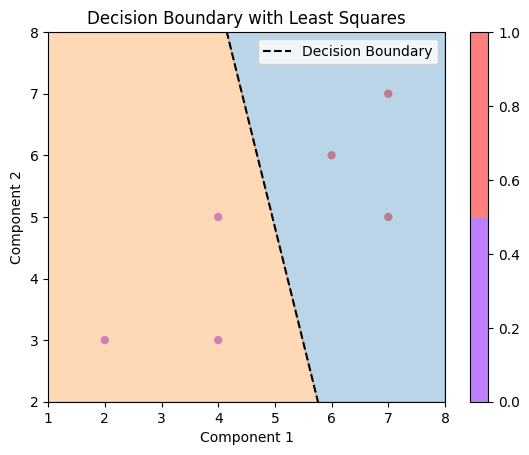

In [10]:
def plot_scatter(data, target, n_class=2, padding=1):
    x_min = np.min(data[0]) - padding
    x_max = np.max(data[0]) + padding
    y_min = np.min(data[1]) - padding
    y_max = np.max(data[1]) + padding
    
    plt.scatter(*data, c=target, edgecolor='none', alpha=0.5, cmap=plt.cm.get_cmap('rainbow', n_class))
    plt.xlabel('Component 1')
    plt.ylabel('Component 2')
    plt.colorbar()
    plt.xlim(x_min, x_max)
    plt.ylim(y_min, y_max)

def plot_decision_boundary(data, ws, w0, padding=1):
    x_min = np.min(data[0]) - padding
    x_max = np.max(data[0]) + padding
    y_min = np.min(data[1]) - padding
    y_max = np.max(data[1]) + padding

    x1=np.linspace(x_min, x_max, 100)
    w1, w2 = ws
    w01, w02 = w0

    # Difference vector
    wd = w1 - w2
    w0d = w01 - w02
    # Boundary: wd[0]*x + wd[1]*y + w0d = 0, solve for y
    a = -wd[0,0] / wd[1,0]
    b = -w0d[0,0] / wd[1,0]
    x2= a * x1 + b

    y_fill_top=np.full(x1.shape,y_max)
    y_fill_bottom=np.full(x1.shape,y_min)
    plt.fill_between(x1,y_fill_top,x2,color='C0',alpha=0.3)
    plt.fill_between(x1,x2,y_fill_bottom,color='C1',alpha=0.3)
    plt.plot(x1,x2,'k--',label='Decision Boundary')
    plt.xlim(x_min, x_max)
    plt.ylim(y_min, y_max)
    plt.xlabel('Component 1')
    plt.ylabel('Component 2')
    plt.title('Decision Boundary with Least Squares')
    plt.legend()

plot_scatter(X, l)
plot_decision_boundary(X, ws, w_0s)

# Topic 3

## 1) (Score: 10%) Can you apply Fisher’s linear discriminant model directly to input data (i.e., without using nonlinear basis functions ϕ(x)) to correctly classify the test data points into the two classes, C1 and C2? If yes, briefly explain how that can be done. If not, why not?

No, the data is spread in a way where a linear boundary could not divide it without a lot of overlap between the two classes.

## 2) (Score: 10%) Can you apply Logistic regression model directly to input data (i.e., without using nonlinear basis functions ϕ(x)) to correctly classify the test data points into the two classes, C1 and C2? If yes, briefly explain how that can be done. If not, why not?

No, the the data can again not be divided by a logistic boundary without a lot of overlap.

## 3) (Score: 10%) Can you apply Linear Support Vector Machines that uses linear kernel κ(x, x′) = xT x′ to classify the test data points into the two classes, C1 and C2, with high classification accuracy. If yes, briefly explain how that can be done. If not, why not?

No, since it will still make a linear boundary which would not be able to divide and classify the data.

## 4) (Score: 20%) There exists a nonlinear transformation yi = ϕ(xi) that will allow the Fisher’s linear discriminant and the Logistic regression model to work well on the above data, in the sense that both classification methods will provide 100% classification accuracy on the test data. Write down that data transformation function yi = ϕ(xi).

It can be seen that the data is spherically clustered. You can therefore use the euclidean distance between the data and the origin as the nonlinear transformation, which would be
$$
y_i = ||\vec{0} - x_i||^2
$$

## 5) (Score: 20%) After applying the nonlinear transformation ϕ(xi) obtained above, draw the transformed data points yi in 1D space. Roughly sketch where the blue squares (training points from C1 class), red diamonds (training points from C2 class), and the black circles (test points) will reside in the transformed space. Also roughly draw the decision boundary of the Logistic regression model applied to this transformed data, and the corresponding decision boundary in the original feature space (Fig. 2). Note that when drawing the transformed data and decision boundaries, just draw their rough arrangement in the new feature space without calculating the exact values.

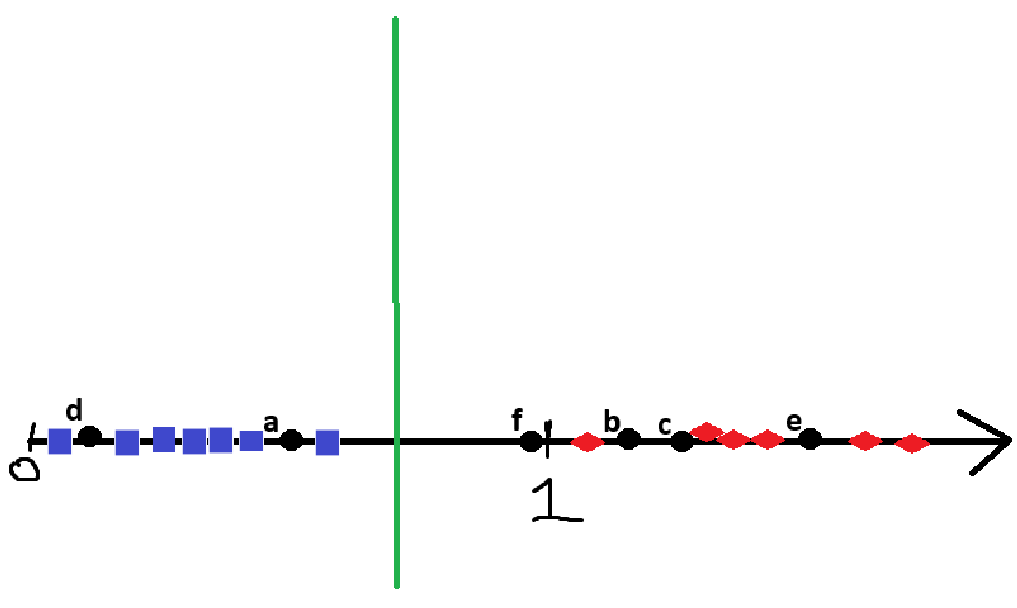

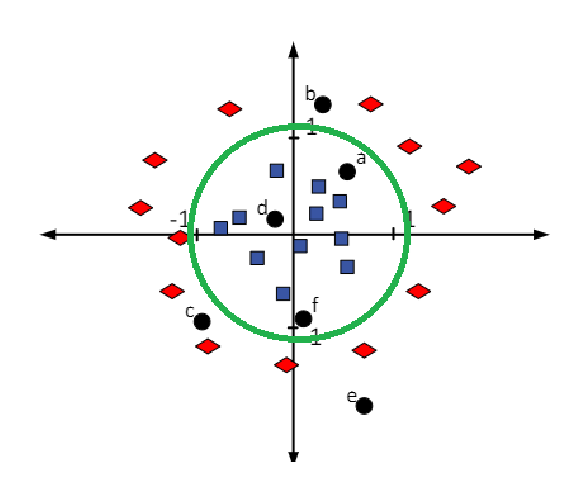

## 6) (Score: 20%) Which suitable kernel function could be used with Support vector machines to enable 100% classification of the test data points using the available training data? Identify the Support vectors in Fig. 2, which shows data in the original space.

The gaussian kernel based on Euclidean distance would be suitable (slide 552):
$$
k(x,x') = \exp\left( -\frac{ ||x - x'||^2 }{ 2\sigma^2 } \right)
$$

The support vectors could potentially be the two points highlighted here, but it depends on whether you use slack variables or not and what the margin is set to.

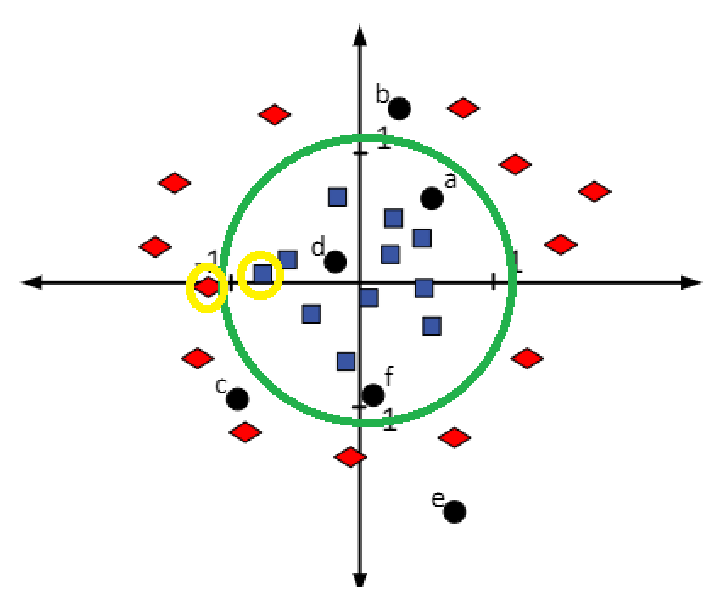

## 7) (Score: 10%) To which class will the test data points a, b, . . . , f be classified using the SVM classifier you used to answer question 6? 

a, d, and f would be in class $C_1$ and b, e, and c would be in class $C_2$.

# Topic 4

## 1) (Score: 15%) For the first data point x1 = [0.1, −0.1]T from the training set, what is the output value of the neural network? Show your intermediate calculations.

The neuron transformations and thereby forward propagation is calculated using the following equations:
$$
a = w^{T}x + w_{0}
$$
$$
z = h(a)
$$

In [ ]:
W_1 = np.array([[0.6, 0.2, -0.1, 0.4],
                [0.7, -1.0, 0.3, 0.2],
                [-0.5, -0.3, -0.4, -0.8]])
W_2 = np.array([[-0.7],
                [0.7],
                [0.6],
                [-0.3],
                [-0.7]])
weigths = [W_1, W_2]

x = np.array([[0.1, -0.1]]).T

# slide 450
def neuron_transformation(x, W, h):
    xbias = np.vstack(([1.0], x))
    a = W.T @ xbias
    print("a =\n", a)
    z = h(a)
    print("z =\n", z)
    return a, z

# slide 452
def sigmoid(a):
    return 1 / (1 + np.exp(-a))

def forward(x, weigths, h):
    activations = []
    outputs = []
    z = x
    for i, W in enumerate(weigths):
        print(f"-- Layer {i+1} calculation steps --")
        a, z = neuron_transformation(z, W, h)
        activations.append(a)
        outputs.append(z)
        print()
    return outputs[-1], activations, outputs

y1, activations, outputs = forward(x, weigths, sigmoid)
print("y =", y1.item())

-- Layer 1 calculation steps --
a =
 [[ 0.72]
 [ 0.13]
 [-0.03]
 [ 0.5 ]]
z =
 [[0.67260702]
 [0.53245431]
 [0.49250056]
 [0.62245933]]

-- Layer 2 calculation steps --
a =
 [[-0.4931742]]
z =
 [[0.37914609]]

y = 0.3791460917211281


## 2) (Score: 15%) Assuming the output of the network is y1 = 0.38 given the data point x1. What is the cross entropy error function value E(t1, y1), if the corresponding target is t1 = 1.

The generel equation for cross entropy error is:
$$
E(t, y) = -\sum^{N}_{n=1} (t_{n} \ln(y_{n}) + (1 - t_{n}) \ln(1 - y_{n}))
$$

The values for $t_1$ and $y_1$ can be inserted into this to get $E(t_1, y_1)$.

In [12]:
# slide 344
def cross_entropy_error(t, y):
    N = len(y)
    E = 0
    for n in range(N):
        E -= t[n] * np.log(y[n]) + (1 - t[n]) * np.log(1 - y[n])
    return E[0]

t1 = np.array([[1]])
print("The value will be E(t_1, y_1) =", cross_entropy_error(t1, y1))

The value will be E(t_1, y_1) = 0.9698336818900924


## 3) (Score: 40%) Given the data point x1 and the target t1, use backpropagation to calculate the following partial derivatives of the error: ∂E(t1,y1) ∂w(2) 1,1 , ∂E(t1,y1) ∂w(1) 2,4 Show your intermediate calculations.

In [ ]:
# slide 452
def sigmoid_derivative(a):
    z = sigmoid(a)
    return z * (1 - z)

def compute_all_gradients(x, t, weights, activations, outputs, y, h_derivative):
    num_layers = len(weights)
    gradients = [None] * num_layers
    deltas = [None] * num_layers
    
    print(f"-- Layer {num_layers} calculation steps --")
    deltas[-1] = y - t
    
    for k in range(num_layers - 2, -1, -1):
        W_no_bias = weights[k + 1][1:, :]
        deltas[k] = (W_no_bias @ deltas[k + 1]) * h_derivative(activations[k])
    
    for k in range(num_layers):
        if k == 0:
            z_prev = np.vstack(([1.0], x))
        else:
            z_prev = np.vstack(([1.0], outputs[k - 1]))
        
        gradients[k] = z_prev @ deltas[k].T

    # gradients = ∂E/∂w and deltas = ∂E/∂a
    return gradients, deltas

gradients, _ = compute_all_gradients(x, t1, weigths, activations, outputs, y1, sigmoid_derivative)

print(gradients[0])
print(gradients[1])

print(f"\n∂E/∂w^(2)_1,1 = {gradients[1][1, 0]}")
print(f"∂E/∂w^(1)_2,4 = {gradients[0][2, 3]}")

-- Layer 2 calculation steps --
[[-0.09570138 -0.09273573  0.04655357  0.10213208]
 [-0.00957014 -0.00927357  0.00465536  0.01021321]
 [ 0.00957014  0.00927357 -0.00465536 -0.01021321]]
[[-0.62085391]
 [-0.4175907 ]
 [-0.33057634]
 [-0.3057709 ]
 [-0.38645631]]

∂E/∂w^(2)_1,1 = -0.4175906952823129
∂E/∂w^(1)_2,4 = -0.010213208122628221


## 4) (Score: 15%) Briefly explain how you will use ∂E(t1,y1) ∂w(1) 2,4 to update the weight w2,4 of the neural network for the 2nd iteration.

The error equates to the gradient between the current value of $w_{2,4}$ and the desired weight. You therefore nudge it in the opposite direction with a learning rate, $\eta$, which controls how much we nudge the value each iteration
$$
w^{\text{{2nd iteration}}}_{2,4} = w^{\text{{1st iteration}}}_{2,4} + \eta \cdot \Delta w_{2,4}
$$

where

$$
\Delta w_{2,4} = - \frac{\partial E(t_1, y_1)}{\partial w^{(1)}_{2,4}}
$$

##  5) (Score: 15%) Briefly explain how this network output could be used for a binary classification task, where we must assign a test input xn to either class C0 (tn = 0) or class C1 (tn = 1). Specifically, if the network output for a test input is y = 0.38, which class will you assign to that input and why?

The output activation function for this network is a sigmoid function, which outputs values between 0 and 1. This is works for binary classification since you can split it up so outputs below 0.5 is classified under class $C_0$ (closer to $t=0$) and outputs above 0.5 are classified under class $C_1$ (closer to $t=1$). If a test input results in an output of $y = 0.38$ it would then be assigned to class $C_0$.